In [1]:
import pandas as pd
import matplotlib.pyplot as plt

df = pd.read_csv('../data/transactions_features.csv')
df.head()

,trans_date_trans_time,cc_num,merchant,category,amt,first,last,gender,street,city,...,unix_time,merch_lat,merch_long,is_fraud,transaction_hour,transaction_day_of_week,transaction_month,age,is_off_hours,category_risk_weight
0,2020-09-18 07:13:39,5359543825610251,"fraud_Jenkins, Hauck and Friesen",gas_transport,59.91,Michael,Francis,M,1833 Jeanette Stravenue,Belgrade,...,1379488419,45.274075,-111.649432,False,7,4,9,45,0,1
1,2020-12-05 17:48:25,5540636818935089,fraud_Jast-McDermott,shopping_pos,3.96,Kenneth,Foster,M,329 Michael Extension,Lawrence,...,1386265705,43.356278,-71.008959,False,17,5,12,35,0,2
2,2019-06-15 11:24:44,2720894374956739,fraud_Bartoletti-Wunsch,gas_transport,51.17,Audrey,Hickman,F,3325 Gregory Square,Mount Clemens,...,1339759484,42.372483,-83.508020,False,11,5,6,92,0,1
3,2020-08-29 22:50:25,6011438889172900,"fraud_Roob, Conn and Tremblay",shopping_pos,2.06,Allison,Allen,F,40624 Rebecca Spurs,De Witt,...,1377816625,33.833389,-91.158293,False,22,5,8,27,0,2
4,2019-07-25 15:50:35,60495593109,"fraud_Kilback, Nitzsche and Leffler",travel,6.58,Randall,Dillon,M,4440 George Mills Suite 591,Dallas,...,1343231435,32.458643,-96.577001,False,15,3,7,77,0,3


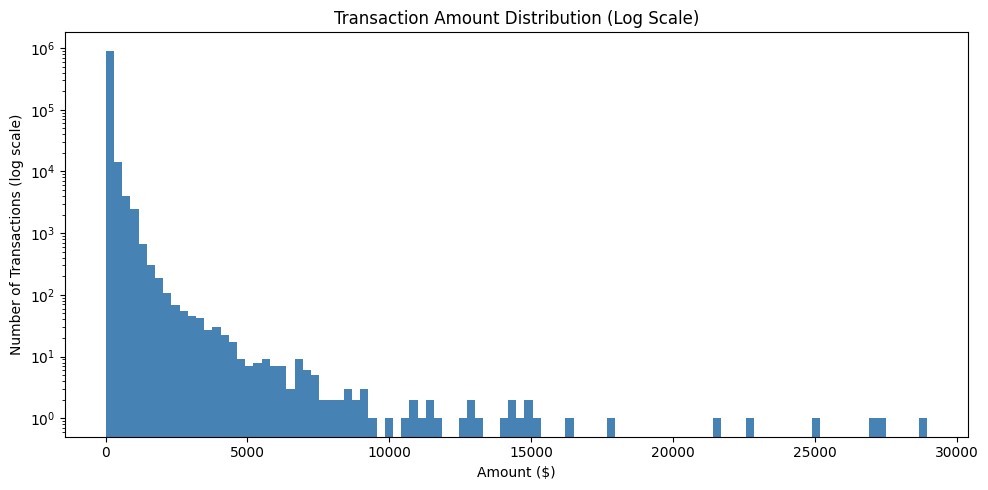

In [2]:
plt.figure(figsize=(10, 5))
plt.hist(df['amt'], bins=100, color='steelblue', edgecolor='none')

plt.title('Transaction Amount Distribution (Log Scale)')
plt.xlabel('Amount ($)')
plt.ylabel('Number of Transactions (log scale)')
plt.yscale('log')

plt.tight_layout()
plt.show()

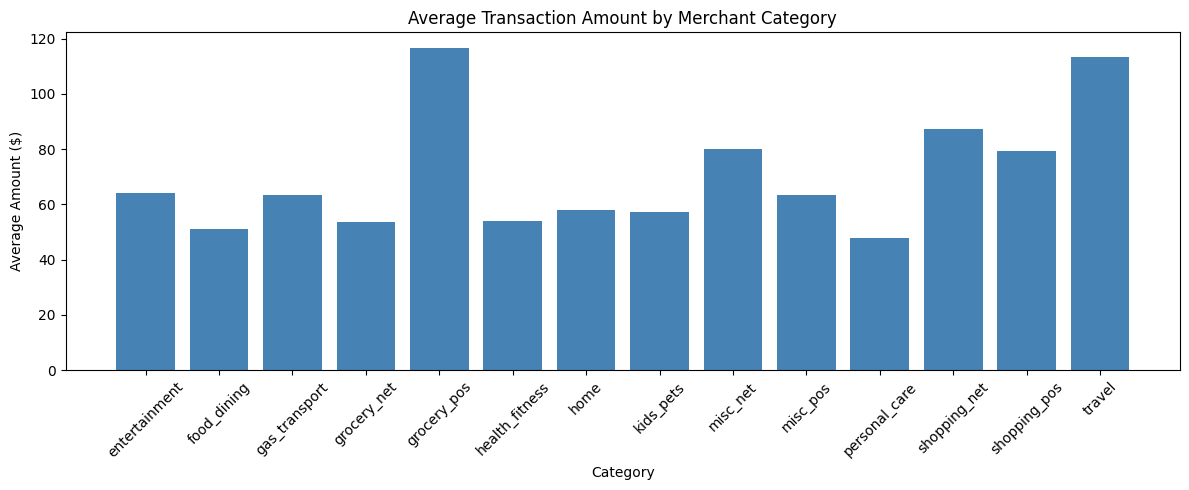

In [3]:
category_spend = df.groupby('category')['amt'].mean()

plt.figure(figsize=(12, 5))
plt.bar(category_spend.index, category_spend.values, color='steelblue')
plt.title('Average Transaction Amount by Merchant Category')
plt.xlabel('Category')
plt.ylabel('Average Amount ($)')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

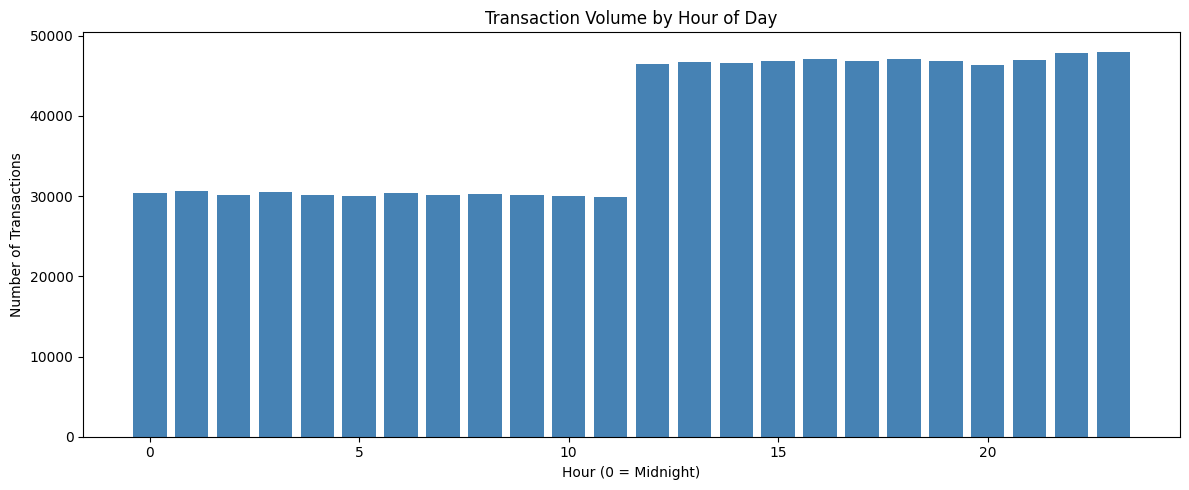

In [4]:
hourly = df.groupby('transaction_hour')['amt'].count()

plt.figure(figsize=(12, 5))
plt.bar(hourly.index, hourly.values, color='steelblue')
plt.title('Transaction Volume by Hour of Day')
plt.xlabel('Hour (0 = Midnight)')
plt.ylabel('Number of Transactions')
plt.tight_layout()
plt.show()

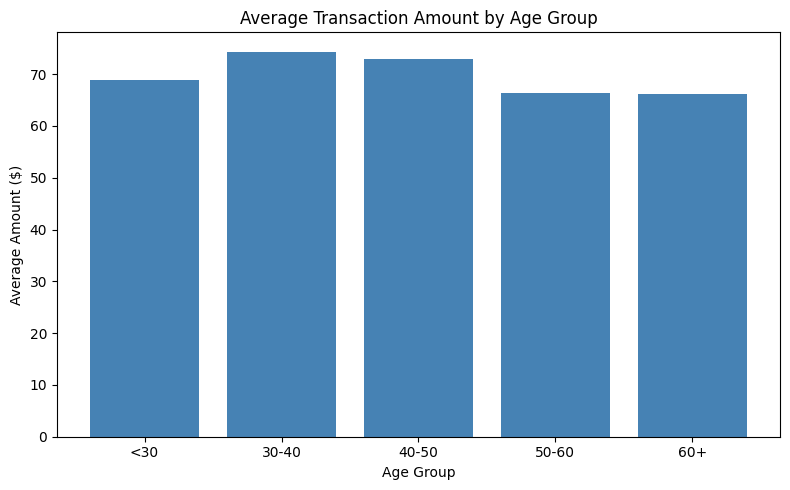

In [5]:
df['age_group'] = pd.cut(df['age'], bins=[0, 30, 40, 50, 60, 100], labels=['<30', '30-40', '40-50', '50-60', '60+'])
age_spend = df.groupby('age_group', observed=True)['amt'].mean()

plt.figure(figsize=(8, 5))
plt.bar(age_spend.index, age_spend.values, color='steelblue')
plt.title('Average Transaction Amount by Age Group')
plt.xlabel('Age Group')
plt.ylabel('Average Amount ($)')
plt.tight_layout()
plt.show()

In [6]:
print(f"Median transaction amount: ${df['amt'].median():.2f}")
print(f"% of transactions under $100: {(df['amt'] < 100).mean()*100:.1f}%")
print(f"Top category by avg spend: {df.groupby('category')['amt'].mean().idxmax()}")
print(f"Peak transaction hour: {df['transaction_hour'].value_counts().idxmax()}:00")
print(f"Highest spending age group: {df.groupby('age_group', observed=True)['amt'].mean().idxmax()}")

Median transaction amount: $47.41
% of transactions under $100: 81.9%
Top category by avg spend: grocery_pos
Peak transaction hour: 23:00
Highest spending age group: 30-40


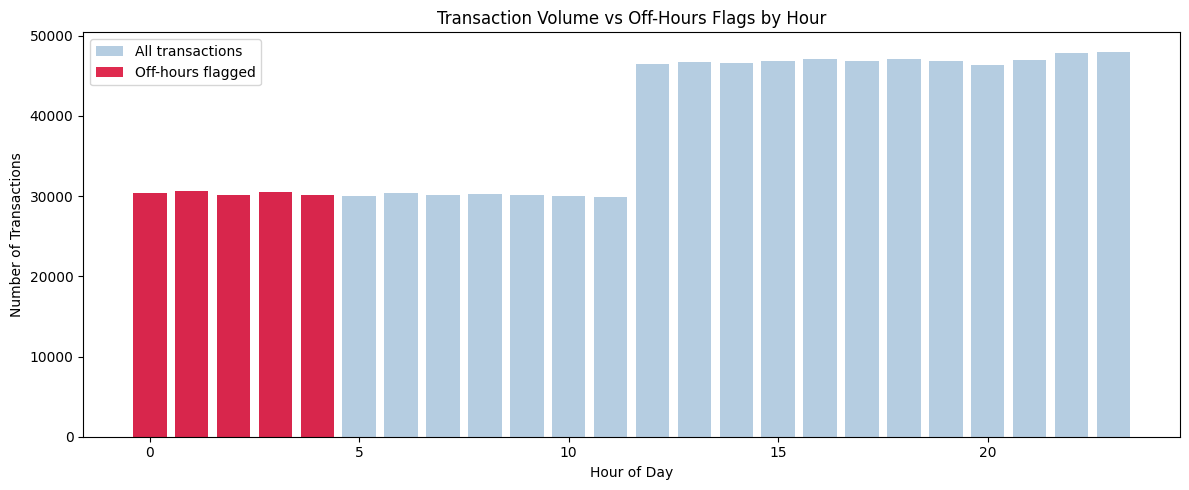

Off-hours transactions: 151,847
% of total: 16.4%


In [7]:
hourly_all = df.groupby('transaction_hour').size()
hourly_off = df[df['is_off_hours'] == 1].groupby('transaction_hour').size()

fig, ax = plt.subplots(figsize=(12, 5))
ax.bar(hourly_all.index, hourly_all.values,
       alpha=0.4, label='All transactions', color='steelblue')
ax.bar(hourly_off.index, hourly_off.values,
       alpha=0.9, label='Off-hours flagged', color='crimson')
ax.set_title('Transaction Volume vs Off-Hours Flags by Hour')
ax.set_xlabel('Hour of Day')
ax.set_ylabel('Number of Transactions')
ax.legend()
plt.tight_layout()
plt.show()

print(f"Off-hours transactions: {df['is_off_hours'].sum():,}")
print(f"% of total: {df['is_off_hours'].mean()*100:.1f}%")

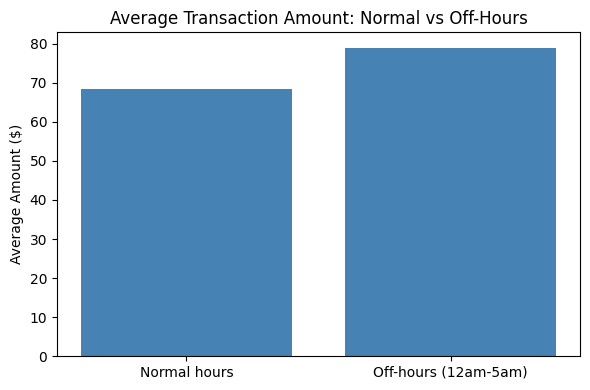

Normal hours avg: $68.42
Off-hours avg:    $78.96


In [8]:
fig, ax = plt.subplots(figsize=(6, 4))
ax.bar(['Normal hours', 'Off-hours (12am-5am)'],
       [df[df['is_off_hours']==0]['amt'].mean(),
        df[df['is_off_hours']==1]['amt'].mean()],
       color='steelblue')
ax.set_title('Average Transaction Amount: Normal vs Off-Hours')
ax.set_ylabel('Average Amount ($)')
plt.tight_layout()
plt.show()

print(f"Normal hours avg: ${df[df['is_off_hours']==0]['amt'].mean():.2f}")
print(f"Off-hours avg:    ${df[df['is_off_hours']==1]['amt'].mean():.2f}")

In [11]:
amt_threshold = df['amt'].quantile(0.95)

df['risk_score_eda'] = (
    (df['amt'] > amt_threshold).astype(int) +
    (df['is_off_hours'] == 1).astype(int) +
    (df['category_risk_weight'] >= 3).astype(int)
)

df['risk_level_eda'] = pd.cut(
    df['risk_score_eda'],
    bins=[-1, 0, 1, 3],
    labels=['Low', 'Medium', 'High']
)

coherence = df.groupby('risk_level_eda', observed=True).agg(
    transaction_count=('amt', 'count'),
    avg_amount=('amt', 'mean'),
    median_amount=('amt', 'median'),
    pct_off_hours=('is_off_hours', 'mean'),
    pct_high_risk_category=('category_risk_weight',
                             lambda x: (x >= 3).mean())
).round(2)

print("=== Signal Coherence by Risk Level ===")
print(coherence)

=== Signal Coherence by Risk Level ===
                transaction_count  avg_amount  median_amount  pct_off_hours  \
risk_level_eda                                                                
Low                        711849       50.10          42.31           0.00   
Medium                     201532      113.73          61.72           0.71   
High                        12816      498.27         336.06           0.71   

                pct_high_risk_category  
risk_level_eda                          
Low                               0.00  
Medium                            0.13  
High                              0.29  


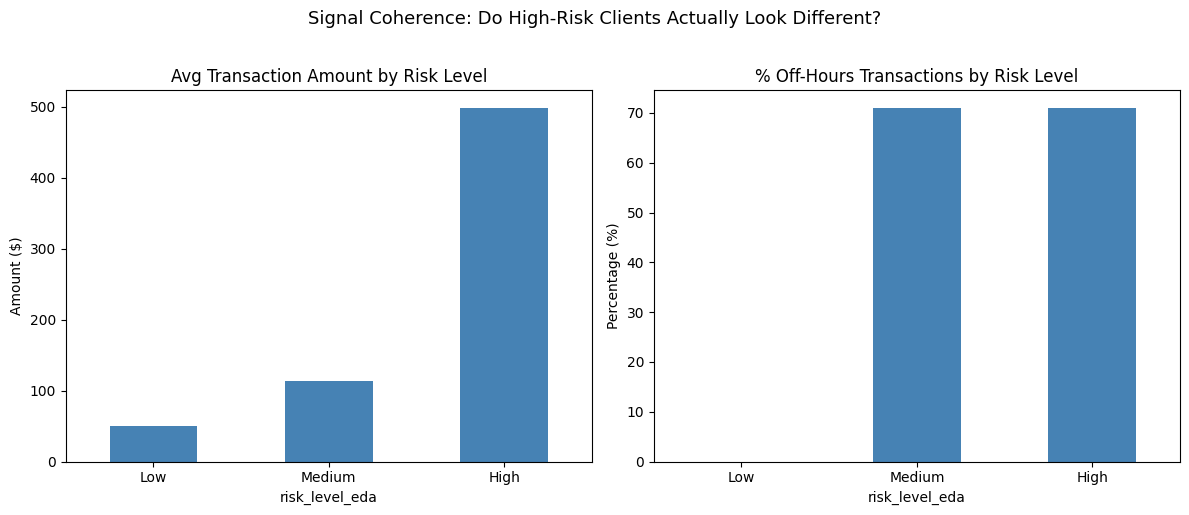

In [12]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

coherence['avg_amount'].plot(kind='bar', ax=axes[0], color='steelblue')
axes[0].set_title('Avg Transaction Amount by Risk Level')
axes[0].set_ylabel('Amount ($)')
axes[0].tick_params(axis='x', rotation=0)

(coherence['pct_off_hours'] * 100).plot(kind='bar', ax=axes[1], color='steelblue')
axes[1].set_title('% Off-Hours Transactions by Risk Level')
axes[1].set_ylabel('Percentage (%)')
axes[1].tick_params(axis='x', rotation=0)

plt.suptitle('Signal Coherence: Do High-Risk Clients Actually Look Different?',
             fontsize=13, y=1.02)
plt.tight_layout()
plt.show()

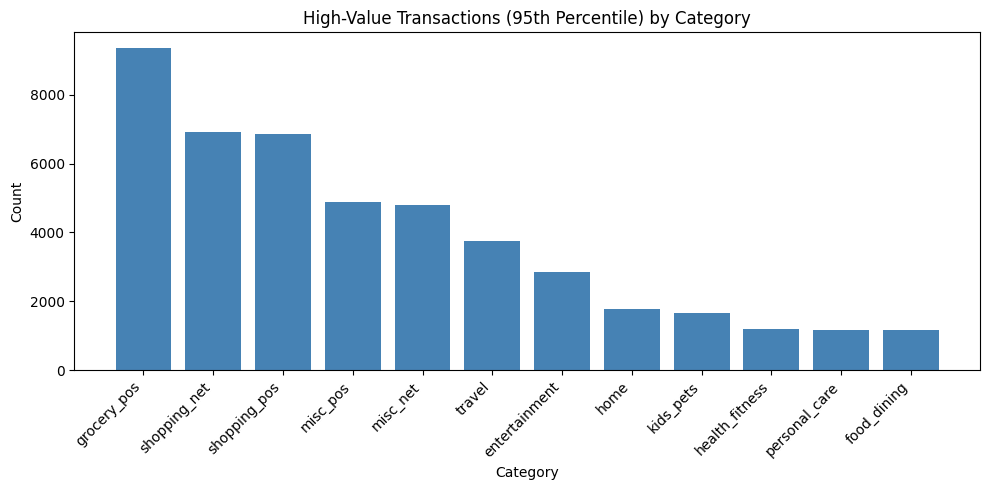

In [9]:
threshold = df['amt'].quantile(0.95)
high_risk = df[df['amt'] > threshold]

plt.figure(figsize=(10, 5))
plt.bar(high_risk['category'].value_counts().index, 
        high_risk['category'].value_counts().values, color='steelblue')
plt.title('High-Value Transactions (95th Percentile) by Category')
plt.xlabel('Category')
plt.ylabel('Count')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

## Key Insights


- Transaction amounts are heavily right-skewed — most transactions are under $1000, but a small number of large transactions drive significant volume
- Shopping and travel categories show the highest average transaction amounts
- Transaction activity peaks in the afternoon hours and drops significantly after midnight
- Clients aged 30-40 tend to have a slightly higher average transaction amounts than other age groups
- grocery_pos categorie accounts for the largest share of high-value transactions (above the 95th percentile threshold)